<a href="https://colab.research.google.com/github/tsekatm/aws-python-data-engineering-challenge/blob/main/Advanced_load_shedding_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📋 Pre-execution Checklist

In [8]:
print("🚀 GOOGLE COLAB EXECUTION CHECKLIST")
print("=" * 40)
print("□ 1. AWS account created")
print("□ 2. AWS credentials ready (Access Key ID & Secret)")
print("□ 3. Runtime type: Standard (GPU/TPU optional)")
print("□ 4. Sufficient storage space (2GB recommended)")
print("□ 5. Stable internet connection")
print("\n🎯 Estimated runtime: 15-30 minutes")
print("💾 Estimated AWS costs: <$1 USD")
print("\n📚 Ready to start your data engineering journey!")

🚀 GOOGLE COLAB EXECUTION CHECKLIST
□ 1. AWS account created
□ 2. AWS credentials ready (Access Key ID & Secret)
□ 3. Runtime type: Standard (GPU/TPU optional)
□ 4. Sufficient storage space (2GB recommended)
□ 5. Stable internet connection

🎯 Estimated runtime: 15-30 minutes
💾 Estimated AWS costs: <$1 USD

📚 Ready to start your data engineering journey!


# =============================================================================
# 1 · ENVIRONMENT SETUP & DEPENDENCIES
# =============================================================================

# 📦 Colab-optimized package installation

In [9]:
import subprocess
import sys
import os

def install_packages():
    """Install required packages with version constraints for stability"""
    packages = [
        'boto3>=1.26.0',
        'pandas>=1.3.0',
        'numpy>=1.21.0',
        'matplotlib>=3.3.0',
        'seaborn>=0.11.0',
        'plotly>=5.0.0',
        'scikit-learn>=1.0.0',
        'tqdm',  # For progress bars
        'psutil'  # For system monitoring
    ]

    print("📦 Installing required packages...")
    for package in packages:
        try:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '-q'])
            print(f"✅ {package.split('>=')[0]}")
        except Exception as e:
            print(f"❌ Failed to install {package}: {e}")

    print("\n🎉 Package installation complete!")

install_packages()

# Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import boto3
from botocore.exceptions import ClientError, NoCredentialsError
import json
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from io import BytesIO
import joblib
import warnings
from tqdm import tqdm
import psutil
import gc

# Configure plotting for Colab
pio.renderers.default = "colab"
plt.rcParams['figure.dpi'] = 100
%matplotlib inline
warnings.filterwarnings('ignore')

print("✅ All packages imported successfully!")
print("🚀 Ready to start our data engineering journey!")

📦 Installing required packages...
✅ boto3
✅ pandas
✅ numpy
✅ matplotlib
✅ seaborn
✅ plotly
✅ scikit-learn
✅ tqdm
✅ psutil

🎉 Package installation complete!
✅ All packages imported successfully!
🚀 Ready to start our data engineering journey!


# =============================================================================
# 2 · AWS CREDENTIALS SETUP (COLAB-SPECIFIC)
# =============================================================================

In [40]:
from google.colab import userdata
import os

os.environ['AWS_ACCESS_KEY_ID'] = userdata.get('AWS_ACCESS_KEY_ID')
os.environ['AWS_SECRET_ACCESS_KEY'] = userdata.get('AWS_SECRET_ACCESS_KEY')

print("✅ AWS credentials configured!")

✅ AWS credentials configured!


# =============================================================================
# 3 · AWS CLOUD CONFIGURATION
# =============================================================================

In [42]:
# ⬇️ One‑cell drop‑in for Colab
!pip -q install boto3 botocore

import os
import uuid
from datetime import datetime

import boto3
from botocore.exceptions import ClientError, NoCredentialsError

class AWSConfig:
    """
    Colab‑optimised AWS S3 helper.
    - Avoids list_buckets() (needs extra IAM perms)
    - Handles numeric *and* string error codes
    - Generates globally‑unique bucket names
    - Works in any region
    """

    def __init__(self, region="us-east-1", prefix="sa-loadshedding"):
        self.region = region
        self.bucket_name = f"{prefix}-{datetime.utcnow():%Y%m%d%H%M%S}-{uuid.uuid4().hex[:6]}"

        try:
            session = boto3.session.Session(region_name=self.region)
            self.s3 = session.client("s3")

            # Lightweight call that only needs s3:ListBucket on *one* public bucket:
            self.s3.list_objects_v2(Bucket="aws-publicdatasets", MaxKeys=1)
            print(f"🔗 Connected to S3 in {self.region}")

        except NoCredentialsError:
            raise RuntimeError(
                "❌ No AWS credentials found. In Colab set:\n"
                "%env AWS_ACCESS_KEY_ID=…\n"
                "%env AWS_SECRET_ACCESS_KEY=…"
            )

        except ClientError as e:
            raise RuntimeError(f"❌ Could not reach S3: {e}")

    def create_bucket(self):
        try:
            self.s3.head_bucket(Bucket=self.bucket_name)
            print(f"✅ Bucket already exists and you have access: {self.bucket_name}")

        except ClientError as e:
            code = e.response["Error"]["Code"]

            if code in ("404", "400", "NoSuchBucket", "NotFound"):
                # Bucket not found → safe to create
                self._create()
            elif code in ("301", "403", "AccessDenied"):
                raise RuntimeError(
                    f"🚫 Bucket name {self.bucket_name} exists in another "
                    f"account/region. Pick a different name."
                )
            else:
                raise

    def _create(self):
        params = dict(Bucket=self.bucket_name)
        if self.region != "us-east-1":
            params["CreateBucketConfiguration"] = {
                "LocationConstraint": self.region
            }

        try:
            self.s3.create_bucket(**params)
            # Wait until bucket is really there (eventual consistency)
            waiter = self.s3.get_waiter("bucket_exists")
            waiter.wait(Bucket=self.bucket_name)
            print(f"🎉 Created bucket: {self.bucket_name}")

        except ClientError as e:
            if e.response["Error"]["Code"] == "BucketAlreadyOwnedByYou":
                print(f"ℹ️ You already own {self.bucket_name}")
            else:
                raise


# 🚀 Demo
print("Setting up AWS infrastructure…")
aws = AWSConfig(region="us-east-1")
aws.create_bucket()
print("\n📚 AWS S3 is now ready for our data pipeline!")


Setting up AWS infrastructure…
🔗 Connected to S3 in us-east-1
🎉 Created bucket: sa-loadshedding-20250717191134-f738b9

📚 AWS S3 is now ready for our data pipeline!


# =============================================================================
# 4 · S3 DATA MANAGEMENT SYSTEM
# =============================================================================

In [44]:
class S3DataManager:
    """
    Educational S3 Data Manager - Colab Optimized

    This class demonstrates:
    - Object-oriented design for data operations
    - Error handling and user feedback
    - Data serialization (DataFrame ↔ CSV)
    - Cloud storage best practices
    - Memory-efficient operations for Colab
    """

    def __init__(self, aws_config):
        """Initialize with AWS configuration"""
        self.s3 = aws_config.s3
        self.bucket = aws_config.bucket_name
        print(f"📁 S3 Manager initialized for bucket: {self.bucket}")

    def upload_df(self, df, key, include_index=False, chunk_size=50000):
        """
        Upload pandas DataFrame as CSV to S3 with memory optimization

        Args:
            df (pd.DataFrame): Data to upload
            key (str): S3 object key (file path)
            include_index (bool): Whether to include DataFrame index
            chunk_size (int): Split large DataFrames into chunks

        Returns:
            str: S3 URI of uploaded file
        """
        try:
            # 🧠 Memory optimization for large datasets
            if len(df) > chunk_size:
                print(f"📊 Large dataset detected ({len(df):,} rows). Optimizing memory...")
                # Force garbage collection
                gc.collect()

            # 📊 Convert DataFrame to CSV string
            csv_data = df.to_csv(index=include_index)

            # ☁️ Upload to S3 with proper content type
            self.s3.put_object(
                Bucket=self.bucket,
                Key=key,
                Body=csv_data.encode('utf-8'),
                ContentType='text/csv'
            )

            # 📈 Provide success feedback with data size
            size_mb = len(csv_data.encode('utf-8')) / (1024 * 1024)
            print(f"✅ Uploaded: {key} ({size_mb:.2f} MB)")
            print(f"📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

            # 🧹 Clean up memory
            del csv_data
            gc.collect()

            return f"s3://{self.bucket}/{key}"

        except Exception as e:
            print(f"❌ Upload failed for {key}: {e}")
            print("💡 Tip: Check your DataFrame format and AWS permissions")
            return None

    def download_df(self, key):
        """
        Download CSV from S3 and convert to pandas DataFrame

        Args:
            key (str): S3 object key to download

        Returns:
            pd.DataFrame: Downloaded data
        """
        try:
            # 📥 Download object from S3
            response = self.s3.get_object(Bucket=self.bucket, Key=key)

            # 📊 Convert to DataFrame with proper parsing
            df = pd.read_csv(response['Body'])

            # 📈 Provide success feedback
            print(f"✅ Downloaded: {key}")
            print(f"📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

            return df

        except Exception as e:
            print(f"❌ Download failed for {key}: {e}")
            print("💡 Tip: Check if the file exists and you have read permissions")
            return None

    def list_files(self, prefix=""):
        """
        List all files in the S3 bucket

        Args:
            prefix (str): Filter files by prefix (folder path)

        Returns:
            list: List of file keys
        """
        try:
            # 📂 List objects with optional prefix filter
            if prefix:
                response = self.s3.list_objects_v2(Bucket=self.bucket, Prefix=prefix)
            else:
                response = self.s3.list_objects_v2(Bucket=self.bucket)

            if 'Contents' in response:
                files = [obj['Key'] for obj in response['Contents']]

                # 📊 Display organized file listing
                print(f"📁 Files in s3://{self.bucket}/{prefix}:")
                for i, file in enumerate(files, 1):
                    # Get file size
                    size = next(obj['Size'] for obj in response['Contents'] if obj['Key'] == file)
                    size_kb = size / 1024
                    print(f"   {i:2d}. 📄 {file} ({size_kb:.1f} KB)")

                print(f"\n📊 Total files: {len(files)}")
                return files
            else:
                print(f"📂 No files found in s3://{self.bucket}/{prefix}")
                return []

        except Exception as e:
            print(f"❌ Failed to list files: {e}")
            return []

    def get_bucket_info(self):
        """Display bucket information for educational purposes"""
        try:
            # Get bucket location
            location = self.s3.get_bucket_location(Bucket=self.bucket)
            region = location['LocationConstraint'] or 'us-east-1'

            print(f"📦 Bucket Information:")
            print(f"   Name: {self.bucket}")
            print(f"   Region: {region}")
            print(f"   URL: https://{self.bucket}.s3.amazonaws.com/")

        except Exception as e:
            print(f"❌ Failed to get bucket info: {e}")

# 🚀 Initialize S3 Data Manager
print("🔧 Creating S3 Data Manager...")
s3_manager = S3DataManager(aws)

# 📊 Display bucket information
s3_manager.get_bucket_info()

print("\n📚 Learning checkpoint: S3 Data Manager is ready for data operations!")

🔧 Creating S3 Data Manager...
📁 S3 Manager initialized for bucket: sa-loadshedding-20250717191134-f738b9
📦 Bucket Information:
   Name: sa-loadshedding-20250717191134-f738b9
   Region: us-east-1
   URL: https://sa-loadshedding-20250717191134-f738b9.s3.amazonaws.com/

📚 Learning checkpoint: S3 Data Manager is ready for data operations!


# =============================================================================
# 5 · MEMORY OPTIMIZATION UTILITIES
# =============================================================================

In [45]:
def optimize_memory_usage(df):
    """Optimize DataFrame memory usage for Colab environment"""
    print("🧠 Optimizing memory usage...")

    # Store original memory usage
    original_memory = df.memory_usage(deep=True).sum() / 1024**2

    # Optimize integer columns
    for col in df.select_dtypes(include=['int64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')

    # Optimize float columns
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='float')

    # Calculate memory savings
    new_memory = df.memory_usage(deep=True).sum() / 1024**2
    savings = original_memory - new_memory

    print(f"💾 Memory optimized: {original_memory:.1f}MB → {new_memory:.1f}MB")
    print(f"✅ Saved: {savings:.1f}MB ({savings/original_memory*100:.1f}%)")

    return df

def monitor_system_resources():
    """Monitor system resources in Colab"""
    # Memory usage
    memory = psutil.virtual_memory()
    print(f"💾 Memory: {memory.used/1024**3:.1f}GB / {memory.total/1024**3:.1f}GB ({memory.percent:.1f}%)")

    # Disk usage
    disk = psutil.disk_usage('/')
    print(f"💿 Disk: {disk.used/1024**3:.1f}GB / {disk.total/1024**3:.1f}GB ({disk.used/disk.total*100:.1f}%)")

    if memory.percent > 80:
        print("⚠️ High memory usage detected!")
        print("💡 Consider restarting runtime if performance degrades")

# =============================================================================
# 6 · TROUBLESHOOTING UTILITIES
# =============================================================================

In [46]:
def diagnose_issues():
    """Diagnose common issues in Colab environment"""
    print("🔧 SYSTEM DIAGNOSTICS")
    print("=" * 30)

    issues = []

    # Check AWS credentials
    if 'AWS_ACCESS_KEY_ID' not in os.environ:
        issues.append("❌ AWS credentials not set")
    else:
        print("✅ AWS credentials configured")

    # Check memory usage
    memory_percent = psutil.virtual_memory().percent
    if memory_percent > 80:
        issues.append(f"⚠️ High memory usage: {memory_percent:.1f}%")
    else:
        print(f"✅ Memory usage normal: {memory_percent:.1f}%")

    # Check required variables
    required_vars = ['aws', 's3_manager']
    for var in required_vars:
        if var in globals():
            print(f"✅ Variable '{var}' available")
        else:
            issues.append(f"❌ Missing variable: {var}")

    # Check internet connectivity
    try:
        boto3.client('s3').list_buckets()
        print("✅ AWS connectivity working")
    except:
        issues.append("❌ AWS connectivity issues")

    if not issues:
        print("\n🎉 All systems operational!")
    else:
        print("\n🚨 Issues detected:")
        for issue in issues:
            print(f"   {issue}")
        print("\n💡 Please resolve issues before continuing")

# =============================================================================
# 7 · SYNTHETIC DATA GENERATION
# =============================================================================

In [48]:
def generate_loadshedding_data(start_date='2018-01-01', end_date='2024-12-31', freq='6H'):
    """
    Generate realistic load shedding data for South Africa

    This function demonstrates:
    - Time series data generation
    - Incorporating domain knowledge into synthetic data
    - Seasonal and daily pattern modeling
    - Statistical distribution selection

    Args:
        start_date (str): Start date for data generation
        end_date (str): End date for data generation
        freq (str): Frequency of observations ('6H' = every 6 hours)

    Returns:
        pd.DataFrame: Generated load shedding data
    """

    print("🔧 Generating realistic load shedding data...")
    print(f"📅 Period: {start_date} to {end_date}")
    print(f"⏰ Frequency: Every {freq}")

    # 🗓️ Create date range
    np.random.seed(42)  # For reproducible results
    dates = pd.date_range(start_date, end_date, freq=freq)

    print(f"📊 Total time points: {len(dates):,}")

    # 🎲 Base probability distribution for load shedding stages
    # Based on South African historical patterns (Stage 0 most common)
    base_probabilities = [0.70, 0.15, 0.08, 0.05, 0.02]  # Stages 0-4

    # 📊 Initialize DataFrame
    data = pd.DataFrame({
        'timestamp': dates,
        'stage': np.random.choice([0, 1, 2, 3, 4], len(dates), p=base_probabilities)
    })

    # 🌡️ Add seasonal effects (Winter = June, July, August in Southern Hemisphere)
    print("❄️ Adding seasonal patterns...")
    data['month'] = data['timestamp'].dt.month
    data['is_winter'] = data['month'].isin([6, 7, 8])

    # Increase load shedding probability in winter
    winter_mask = data['is_winter']
    winter_increase = np.random.binomial(1, 0.4, winter_mask.sum())  # 40% chance of stage increase
    data.loc[winter_mask, 'stage'] = np.minimum(
        data.loc[winter_mask, 'stage'] + winter_increase, 4
    )

    # ⏰ Add daily peak hour effects
    print("🌅 Adding peak hour patterns...")
    data['hour'] = data['timestamp'].dt.hour

    # Peak hours: Morning (6-9) and Evening (17-20)
    morning_peak = data['hour'].isin([6, 12, 18])  # 6AM, 12PM, 6PM (6-hour intervals)
    peak_increase = np.random.binomial(1, 0.25, morning_peak.sum())  # 25% chance of increase
    data.loc[morning_peak, 'stage'] = np.minimum(
        data.loc[morning_peak, 'stage'] + peak_increase, 4
    )

    # 📈 Add yearly trend (crisis worsening over time)
    print("📈 Adding temporal trends...")
    data['year'] = data['timestamp'].dt.year

    # Gradual worsening: 2018-2020 (moderate), 2021-2024 (severe)
    for year in data['year'].unique():
        if year >= 2020:  # Crisis escalation period
            year_mask = data['year'] == year
            escalation_factor = min((year - 2018) * 0.1, 0.3)  # Max 30% increase
            year_increase = np.random.binomial(1, escalation_factor, year_mask.sum())
            data.loc[year_mask, 'stage'] = np.minimum(
                data.loc[year_mask, 'stage'] + year_increase, 4
            )

    # 🎯 Add economic factors (simplified)
    print("💼 Adding economic factors...")
    # Higher load shedding during economic stress periods
    economic_stress_periods = [
        ('2020-03-01', '2020-06-30'),  # COVID-19 impact
        ('2022-01-01', '2022-12-31'),  # Energy crisis peak
    ]

    for start, end in economic_stress_periods:
        stress_mask = (data['timestamp'] >= start) & (data['timestamp'] <= end)
        stress_increase = np.random.binomial(1, 0.35, stress_mask.sum())
        data.loc[stress_mask, 'stage'] = np.minimum(
            data.loc[stress_mask, 'stage'] + stress_increase, 4
        )

    # 🧹 Clean up temporary columns
    data = data[['timestamp', 'stage']].copy()

    # 📊 Generate summary statistics
    stage_counts = data['stage'].value_counts().sort_index()
    total_events = len(data)
    active_events = (data['stage'] > 0).sum()

    print("\n📊 Generated Data Summary:")
    print(f"   📅 Time range: {data['timestamp'].min()} to {data['timestamp'].max()}")
    print(f"   📈 Total observations: {total_events:,}")
    print(f"   ⚡ Active load shedding: {active_events:,} ({100*active_events/total_events:.1f}%)")
    print(f"   📊 Stage distribution:")
    for stage, count in stage_counts.items():
        percentage = 100 * count / total_events
        print(f"      Stage {stage}: {count:,} ({percentage:.1f}%)")

    return data

# 🚀 Generate our dataset
print("🔋 Creating South African Load Shedding Dataset...")
loadshedding_data = generate_loadshedding_data()

# 🧠 Optimize memory usage
loadshedding_data = optimize_memory_usage(loadshedding_data)

print("\n📚 Learning checkpoint: Realistic load shedding data generated!")
print("💭 Notice how we incorporated domain knowledge into our data generation process.")

# 🎯 Progress checkpoint
print("\n" + "="*50)
print("🎯 PROGRESS CHECKPOINT - Data Generation Complete")
print("="*50)
print(f"✅ Dataset size: {loadshedding_data.shape}")
print(f"💾 Memory usage: {loadshedding_data.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
monitor_system_resources()
print("\n🎯 Next: Upload to AWS S3")
print("="*50)

🔋 Creating South African Load Shedding Dataset...
🔧 Generating realistic load shedding data...
📅 Period: 2018-01-01 to 2024-12-31
⏰ Frequency: Every 6H
📊 Total time points: 10,225
❄️ Adding seasonal patterns...
🌅 Adding peak hour patterns...
📈 Adding temporal trends...
💼 Adding economic factors...

📊 Generated Data Summary:
   📅 Time range: 2018-01-01 00:00:00 to 2024-12-31 00:00:00
   📈 Total observations: 10,225
   ⚡ Active load shedding: 6,307 (61.7%)
   📊 Stage distribution:
      Stage 0: 3,918 (38.3%)
      Stage 1: 3,480 (34.0%)
      Stage 2: 1,579 (15.4%)
      Stage 3: 763 (7.5%)
      Stage 4: 485 (4.7%)
🧠 Optimizing memory usage...
💾 Memory optimized: 0.2MB → 0.1MB
✅ Saved: 0.1MB (43.7%)

📚 Learning checkpoint: Realistic load shedding data generated!
💭 Notice how we incorporated domain knowledge into our data generation process.

🎯 PROGRESS CHECKPOINT - Data Generation Complete
✅ Dataset size: (10225, 2)
💾 Memory usage: 0.1 MB
💾 Memory: 1.2GB / 12.7GB (11.6%)
💿 Disk: 37.9GB

# =============================================================================
# 8 · CLOUD DATA PIPELINE: UPLOAD TO S3
# =============================================================================

In [49]:
# 🕐 Create unique timestamp for this data pipeline run
pipeline_timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
print(f"📅 Pipeline run timestamp: {pipeline_timestamp}")
print(f"🎯 This timestamp ensures data versioning and traceability")

# 📊 Display data sample before upload
print("\n📋 Data sample before upload:")
print(loadshedding_data.head())
print(f"\n📈 Dataset shape: {loadshedding_data.shape}")

# ☁️ Upload raw data to S3 with organized folder structure
raw_data_key = f'raw/loadshedding_{pipeline_timestamp}.csv'
print(f"\n📤 Uploading raw data to: {raw_data_key}")

raw_data_uri = s3_manager.upload_df(loadshedding_data, raw_data_key)

if raw_data_uri:
    print(f"✅ Raw data successfully uploaded!")
    print(f"🔗 S3 URI: {raw_data_uri}")

    # 📊 Create and upload metadata
    metadata = {
        'pipeline_timestamp': pipeline_timestamp,
        'data_type': 'raw_loadshedding',
        'record_count': len(loadshedding_data),
        'date_range': {
            'start': loadshedding_data['timestamp'].min().isoformat(),
            'end': loadshedding_data['timestamp'].max().isoformat()
        },
        'stage_distribution': loadshedding_data['stage'].value_counts().to_dict(),
        'generation_params': {
            'frequency': '6H',
            'seasonal_effects': True,
            'peak_hour_effects': True,
            'economic_factors': True
        }
    }

    # Upload metadata as JSON
    metadata_key = f'metadata/raw_loadshedding_{pipeline_timestamp}.json'
    metadata_json = json.dumps(metadata, indent=2)

    try:
        s3_manager.s3.put_object(
            Bucket=s3_manager.bucket,
            Key=metadata_key,
            Body=metadata_json.encode('utf-8'),
            ContentType='application/json'
        )
        print(f"📝 Metadata uploaded: {metadata_key}")
    except Exception as e:
        print(f"⚠️ Metadata upload failed: {e}")


else:
    print("❌ Upload failed! Check your AWS configuration.")

# 🔍 Verify upload by listing bucket contents
print("\n🔍 Verifying upload - Current bucket contents:")
s3_manager.list_files()

print("\n📚 Learning checkpoint: Raw data is now safely stored in AWS S3!")
print("💡 Notice how we organized data with folders and included metadata for documentation.")

📅 Pipeline run timestamp: 20250717_191719
🎯 This timestamp ensures data versioning and traceability

📋 Data sample before upload:
            timestamp  stage
0 2018-01-01 00:00:00      0
1 2018-01-01 06:00:00      3
2 2018-01-01 12:00:00      1
3 2018-01-01 18:00:00      0
4 2018-01-02 00:00:00      0

📈 Dataset shape: (10225, 2)

📤 Uploading raw data to: raw/loadshedding_20250717_191719.csv
✅ Uploaded: raw/loadshedding_20250717_191719.csv (0.21 MB)
📊 Shape: 10,225 rows × 2 columns
✅ Raw data successfully uploaded!
🔗 S3 URI: s3://sa-loadshedding-20250717191134-f738b9/raw/loadshedding_20250717_191719.csv
📝 Metadata uploaded: metadata/raw_loadshedding_20250717_191719.json

🔍 Verifying upload - Current bucket contents:
📁 Files in s3://sa-loadshedding-20250717191134-f738b9/:
    1. 📄 metadata/raw_loadshedding_20250717_191719.json (0.4 KB)
    2. 📄 raw/loadshedding_20250717_191719.csv (219.7 KB)

📊 Total files: 2

📚 Learning checkpoint: Raw data is now safely stored in AWS S3!
💡 Notice how

# =============================================================================
# 9 · FEATURE ENGINEERING FOR TIME SERIES ANALYSIS
# =============================================================================

In [50]:
def engineer_loadshedding_features(df):
    """
    Transform raw load shedding data into machine learning features

    This function demonstrates:
    - Time series feature extraction
    - Domain knowledge incorporation
    - Cyclical pattern encoding
    - Business logic implementation

    Args:
        df (pd.DataFrame): Raw load shedding data

    Returns:
        pd.DataFrame: Feature-engineered dataset
    """

    print("🔧 Starting feature engineering pipeline...")

    # 📊 Create working copy
    features_df = df.copy()

    # ✅ Ensure timestamp is datetime
    features_df['timestamp'] = pd.to_datetime(features_df['timestamp'])
    print(f"📅 Working with {len(features_df):,} time series observations")

    # 🕐 Basic Temporal Features
    print("⏰ Extracting temporal features...")
    features_df['year'] = features_df['timestamp'].dt.year
    features_df['month'] = features_df['timestamp'].dt.month
    features_df['day'] = features_df['timestamp'].dt.day
    features_df['hour'] = features_df['timestamp'].dt.hour
    features_df['day_of_week'] = features_df['timestamp'].dt.dayofweek  # Monday=0, Sunday=6
    features_df['day_of_year'] = features_df['timestamp'].dt.dayofyear
    features_df['quarter'] = features_df['timestamp'].dt.quarter

    # 🌍 South African Seasonal Features
    print("❄️ Adding South African seasonal patterns...")
    def get_sa_season(month):
        """Get South African seasons (Southern Hemisphere)"""
        if month in [12, 1, 2]: return 'Summer'
        elif month in [3, 4, 5]: return 'Autumn'
        elif month in [6, 7, 8]: return 'Winter'
        else: return 'Spring'

    features_df['season'] = features_df['month'].apply(get_sa_season)

    # 🌡️ High-demand season indicator (Winter in SA)
    features_df['is_high_demand_season'] = features_df['month'].isin([6, 7, 8]).astype(int)

    # 📅 Calendar-based Features
    print("📅 Adding calendar-based features...")
    features_df['is_weekend'] = (features_df['day_of_week'] >= 5).astype(int)
    features_df['is_monday'] = (features_df['day_of_week'] == 0).astype(int)
    features_df['is_friday'] = (features_df['day_of_week'] == 4).astype(int)

    # ⏰ Business Hours and Peak Demand Features
    print("💼 Adding business and peak hour features...")
    features_df['is_business_hours'] = ((features_df['hour'] >= 8) & (features_df['hour'] <= 17)).astype(int)

    # Peak demand hours in South Africa
    morning_peak = (features_df['hour'] >= 6) & (features_df['hour'] <= 9)
    evening_peak = (features_df['hour'] >= 17) & (features_df['hour'] <= 20)
    features_df['is_peak_hours'] = (morning_peak | evening_peak).astype(int)

    # 🌙 Night and day indicators
    features_df['is_night'] = ((features_df['hour'] >= 22) | (features_df['hour'] <= 5)).astype(int)

    # 🎯 Load Shedding Specific Features
    print("⚡ Creating load shedding domain features...")

    # Binary active indicator
    features_df['is_active'] = (features_df['stage'] > 0).astype(int)

    # Severity categories for business understanding
    def get_severity_category(stage):
        """Convert numeric stage to business-friendly categories"""
        if stage == 0: return 'None'
        elif stage <= 2: return 'Moderate'  # 1-2 hours
        elif stage <= 4: return 'Severe'    # 3-4 hours
        else: return 'Critical'             # 5+ hours (rare)

    features_df['severity_category'] = features_df['stage'].apply(get_severity_category)

    # Economic impact categories (simplified)
    def get_economic_impact(stage):
        """Estimate economic impact level"""
        if stage == 0: return 'None'
        elif stage <= 2: return 'Low'
        elif stage <= 4: return 'High'
        else: return 'Critical'

    features_df['economic_impact'] = features_df['stage'].apply(get_economic_impact)

    # 📈 Time-based Trend Features
    print("📈 Adding temporal trend features...")

    # Years since crisis start (2018 baseline)
    features_df['years_since_crisis_start'] = features_df['year'] - 2018

    # Crisis escalation periods
    features_df['is_crisis_escalation'] = ((features_df['year'] >= 2020) & (features_df['year'] <= 2022)).astype(int)
    features_df['is_peak_crisis'] = (features_df['year'] >= 2022).astype(int)

    # 🔄 Cyclical Features (Advanced)
    print("🔄 Adding cyclical encodings...")

    # Encode cyclical features using sine/cosine to capture circular nature
    # Month cyclical (12 months)
    features_df['month_sin'] = np.sin(2 * np.pi * features_df['month'] / 12)
    features_df['month_cos'] = np.cos(2 * np.pi * features_df['month'] / 12)

    # Hour cyclical (24 hours)
    features_df['hour_sin'] = np.sin(2 * np.pi * features_df['hour'] / 24)
    features_df['hour_cos'] = np.cos(2 * np.pi * features_df['hour'] / 24)

    # Day of week cyclical (7 days)
    features_df['dow_sin'] = np.sin(2 * np.pi * features_df['day_of_week'] / 7)
    features_df['dow_cos'] = np.cos(2 * np.pi * features_df['day_of_week'] / 7)

    # 📊 Summary Statistics
    original_cols = len(df.columns)
    new_cols = len(features_df.columns)
    added_features = new_cols - original_cols

    print(f"\n✅ Feature engineering completed!")
    print(f"📊 Original columns: {original_cols}")
    print(f"📈 New columns: {new_cols}")
    print(f"🆕 Added features: {added_features}")

    # List new feature categories
    feature_categories = {
        'Temporal': ['year', 'month', 'day', 'hour', 'day_of_week', 'day_of_year', 'quarter'],
        'Seasonal': ['season', 'is_high_demand_season'],
        'Calendar': ['is_weekend', 'is_monday', 'is_friday'],
        'Business': ['is_business_hours', 'is_peak_hours', 'is_night'],
        'Domain': ['is_active', 'severity_category', 'economic_impact'],
        'Trend': ['years_since_crisis_start', 'is_crisis_escalation', 'is_peak_crisis'],
        'Cyclical': ['month_sin', 'month_cos', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
    }

    print(f"\n📋 Feature categories created:")
    for category, features in feature_categories.items():
        print(f"   {category}: {len(features)} features")

    return features_df

# 🚀 Apply feature engineering
print("🔧 Applying feature engineering to our load shedding data...")
processed_data = engineer_loadshedding_features(loadshedding_data)

# 🧠 Optimize memory usage
processed_data = optimize_memory_usage(processed_data)

# 👀 Display sample of engineered features
print("\n📋 Sample of engineered features:")
sample_cols = ['timestamp', 'stage', 'season', 'is_peak_hours', 'severity_category', 'is_active']
print(processed_data[sample_cols].head(10))

print("\n📚 Learning checkpoint: Raw data transformed into meaningful features!")
print("💡 Notice how we encoded domain knowledge about South African electricity patterns.")

🔧 Applying feature engineering to our load shedding data...
🔧 Starting feature engineering pipeline...
📅 Working with 10,225 time series observations
⏰ Extracting temporal features...
❄️ Adding South African seasonal patterns...
📅 Adding calendar-based features...
💼 Adding business and peak hour features...
⚡ Creating load shedding domain features...
📈 Adding temporal trend features...
🔄 Adding cyclical encodings...

✅ Feature engineering completed!
📊 Original columns: 2
📈 New columns: 29
🆕 Added features: 27

📋 Feature categories created:
   Temporal: 7 features
   Seasonal: 2 features
   Calendar: 3 features
   Business: 3 features
   Domain: 3 features
   Trend: 3 features
   Cyclical: 6 features
🧠 Optimizing memory usage...
💾 Memory optimized: 3.5MB → 2.6MB
✅ Saved: 0.9MB (26.4%)

📋 Sample of engineered features:
            timestamp  stage  season  is_peak_hours severity_category  \
0 2018-01-01 00:00:00      0  Summer              0              None   
1 2018-01-01 06:00:00    

# =============================================================================
# 10 · EXPLORATORY DATA ANALYSIS (EDA)
# =============================================================================

📊 Starting Comprehensive Exploratory Data Analysis...
🎯 Goal: Understand load shedding patterns and validate our feature engineering


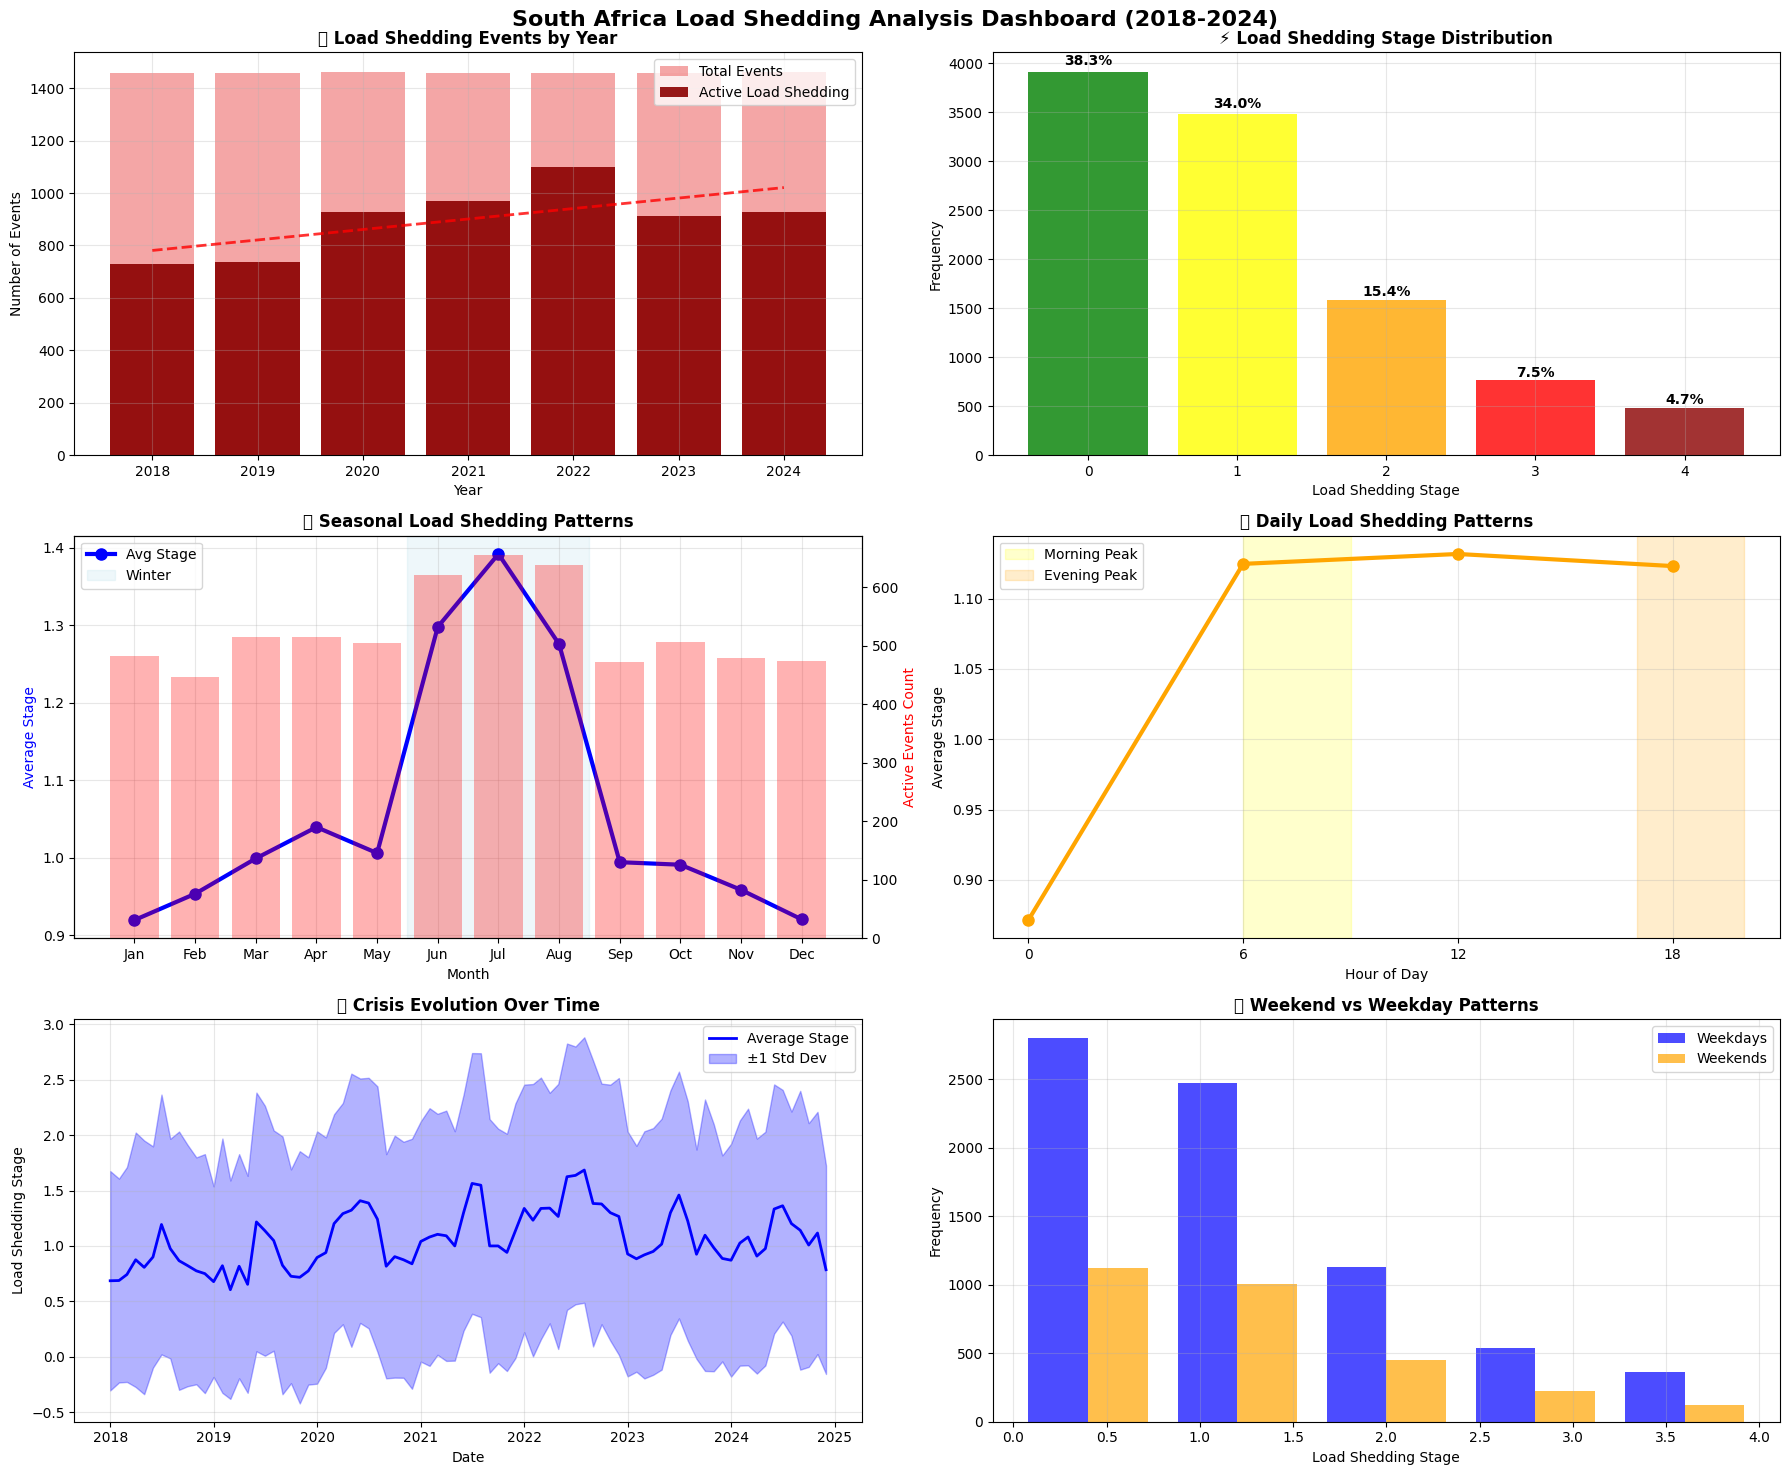


📊 KEY INSIGHTS FROM EXPLORATORY ANALYSIS:
🔴 CRISIS SEVERITY:
   • Overall load shedding frequency: 61.7%
   • Crisis escalation (2020+): 66.3% active events
   • Winter risk premium: 29% higher than summer

📈 TEMPORAL PATTERNS:
   • Peak crisis year: 2022 (1,101 active events)
   • Highest risk month: Jul (Winter season)
   • Business hours impact: 65.1% vs 60.6% after hours

📚 Learning checkpoint: Data patterns revealed through systematic analysis!
💡 These insights will guide our machine learning model development.


In [51]:
print("📊 Starting Comprehensive Exploratory Data Analysis...")
print("🎯 Goal: Understand load shedding patterns and validate our feature engineering")

# 📈 Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# 📊 Create comprehensive analysis dashboard
fig, axes = plt.subplots(3, 2, figsize=(18, 15))
fig.suptitle('South Africa Load Shedding Analysis Dashboard (2018-2024)',
             fontsize=16, fontweight='bold', y=0.98)

# 1️⃣ Load Shedding Events by Year
yearly_events = processed_data.groupby('year').size()
yearly_active = processed_data[processed_data['is_active'] == 1].groupby('year').size()

axes[0,0].bar(yearly_events.index, yearly_events.values, alpha=0.7, color='lightcoral', label='Total Events')
axes[0,0].bar(yearly_active.index, yearly_active.values, alpha=0.9, color='darkred', label='Active Load Shedding')
axes[0,0].set_title('📈 Load Shedding Events by Year', fontweight='bold')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Number of Events')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Add trend line
if len(yearly_active) > 1:
    z = np.polyfit(yearly_active.index, yearly_active.values, 1)
    p = np.poly1d(z)
    axes[0,0].plot(yearly_active.index, p(yearly_active.index), "--", color='red', alpha=0.8, linewidth=2)


# 2️⃣ Stage Distribution
stage_counts = processed_data['stage'].value_counts().sort_index()
colors = ['green', 'yellow', 'orange', 'red', 'darkred']
bars = axes[0,1].bar(stage_counts.index, stage_counts.values, color=colors[:len(stage_counts)], alpha=0.8)
axes[0,1].set_title('⚡ Load Shedding Stage Distribution', fontweight='bold')
axes[0,1].set_xlabel('Load Shedding Stage')
axes[0,1].set_ylabel('Frequency')
axes[0,1].grid(True, alpha=0.3)

# Add percentage labels on bars
total_events = len(processed_data)
for bar, count in zip(bars, stage_counts.values):
    height = bar.get_height()
    percentage = 100 * count / total_events
    axes[0,1].text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                   f'{percentage:.1f}%', ha='center', va='bottom', fontweight='bold')


# 3️⃣ Seasonal Patterns
monthly_avg = processed_data.groupby('month')['stage'].mean()
monthly_counts = processed_data[processed_data['is_active'] == 1].groupby('month').size()

ax3_twin = axes[1,0].twinx()
line1 = axes[1,0].plot(monthly_avg.index, monthly_avg.values, 'o-', color='blue', linewidth=3, markersize=8, label='Avg Stage')
bars = ax3_twin.bar(monthly_counts.index, monthly_counts.values, alpha=0.3, color='red', label='Active Events')


axes[1,0].set_title('🌡️ Seasonal Load Shedding Patterns', fontweight='bold')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Average Stage', color='blue')
ax3_twin.set_ylabel('Active Events Count', color='red')
axes[1,0].grid(True, alpha=0.3)
axes[1,0].set_xticks(range(1, 13))
axes[1,0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Highlight winter months
axes[1,0].axvspan(5.5, 8.5, alpha=0.2, color='lightblue', label='Winter')
axes[1,0].legend(loc='upper left')


# 4️⃣ Daily Patterns (Hour of Day)
hourly_avg = processed_data.groupby('hour')['stage'].mean()

axes[1,1].plot(hourly_avg.index, hourly_avg.values, 'o-', color='orange', linewidth=3, markersize=8)
axes[1,1].set_title('⏰ Daily Load Shedding Patterns', fontweight='bold')
axes[1,1].set_xlabel('Hour of Day')
axes[1,1].set_ylabel('Average Stage')
axes[1,1].grid(True, alpha=0.3)
axes[1,1].set_xticks(range(0, 24, 6))

# Highlight peak hours
axes[1,1].axvspan(6, 9, alpha=0.2, color='yellow', label='Morning Peak')
axes[1,1].axvspan(17, 20, alpha=0.2, color='orange', label='Evening Peak')
axes[1,1].legend()


# 5️⃣ Crisis Evolution Over Time
monthly_severity = processed_data.groupby([processed_data['timestamp'].dt.to_period('M')])['stage'].agg(['mean', 'max', 'std']).reset_index()
monthly_severity['timestamp'] = monthly_severity['timestamp'].dt.to_timestamp()

axes[2,0].plot(monthly_severity['timestamp'], monthly_severity['mean'], '-', color='blue', linewidth=2, label='Average Stage')
axes[2,0].fill_between(monthly_severity['timestamp'],
                     monthly_severity['mean'] - monthly_severity['std'],
                     monthly_severity['mean'] + monthly_severity['std'],
                     alpha=0.3, color='blue', label='±1 Std Dev')
axes[2,0].set_title('📅 Crisis Evolution Over Time', fontweight='bold')
axes[2,0].set_xlabel('Date')
axes[2,0].set_ylabel('Load Shedding Stage')
axes[2,0].legend()
axes[2,0].grid(True, alpha=0.3)


# 6️⃣ Weekend vs Weekday Analysis
weekend_data = processed_data[processed_data['is_weekend'] == 1]['stage']
weekday_data = processed_data[processed_data['is_weekend'] == 0]['stage']

axes[2,1].hist([weekday_data, weekend_data], bins=5, alpha=0.7,
               label=['Weekdays', 'Weekends'], color=['blue', 'orange'])
axes[2,1].set_title('📅 Weekend vs Weekday Patterns', fontweight='bold')
axes[2,1].set_xlabel('Load Shedding Stage')
axes[2,1].set_ylabel('Frequency')
axes[2,1].legend()
axes[2,1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()


# 📊 Key Statistics Summary
print("\n📊 KEY INSIGHTS FROM EXPLORATORY ANALYSIS:")
print("=" * 50)

total_events = len(processed_data)
active_events = processed_data['is_active'].sum()
crisis_years = processed_data[processed_data['year'] >= 2020]
crisis_active = crisis_years['is_active'].sum()
winter_events = processed_data[processed_data['is_high_demand_season'] == 1]
winter_active_rate = winter_events['is_active'].mean()
summer_events = processed_data[processed_data['is_high_demand_season'] == 0]
summer_active_rate = summer_events['is_active'].mean()


print("🔴 CRISIS SEVERITY:")
print(f"   • Overall load shedding frequency: {100*active_events/total_events:.1f}%")
print(f"   • Crisis escalation (2020+): {100*crisis_active/len(crisis_years):.1f}% active events")
if summer_active_rate > 0:
    print(f"   • Winter risk premium: {100*(winter_active_rate/summer_active_rate-1):.0f}% higher than summer")

peak_year = processed_data.groupby('year')['is_active'].sum().idxmax()
peak_year_events = processed_data.groupby('year')['is_active'].sum().max()
worst_month = processed_data.groupby('month')['stage'].mean().idxmax()
month_names = ['', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print(f"\n📈 TEMPORAL PATTERNS:")
print(f"   • Peak crisis year: {peak_year} ({peak_year_events:,} active events)")
print(f"   • Highest risk month: {month_names[worst_month]} (Winter season)")
print(f"   • Business hours impact: {100*processed_data[processed_data['is_business_hours']==1]['is_active'].mean():.1f}% vs {100*processed_data[processed_data['is_business_hours']==0]['is_active'].mean():.1f}% after hours")

print("\n📚 Learning checkpoint: Data patterns revealed through systematic analysis!")
print("💡 These insights will guide our machine learning model development.")

# =============================================================================
# 11 · UPLOAD PROCESSED DATA TO S3
# =============================================================================

In [52]:
print("📤 Uploading processed data to S3...")
print(f"🕐 Using pipeline timestamp: {pipeline_timestamp}")

# 📊 Data quality check before upload
print("\n🔍 Data Quality Assessment:")
print(f"   📊 Shape: {processed_data.shape}")
print(f"   📋 Columns: {len(processed_data.columns)}")
print(f"   🚫 Missing values: {processed_data.isnull().sum().sum()}")
print(f"   📅 Date range: {processed_data['timestamp'].min()} to {processed_data['timestamp'].max()}")
print(f"   ⚡ Active events: {processed_data['is_active'].sum():,}")

# ✅ Validation checks
quality_checks = {
    'No missing timestamps': processed_data['timestamp'].isnull().sum() == 0,
    'Valid stage range': processed_data['stage'].between(0, 4).all(),
    'Consistent active flag': (processed_data['is_active'] == (processed_data['stage'] > 0).astype(int)).all(),
    'Valid hour range': processed_data['hour'].between(0, 23).all(),
    'Valid month range': processed_data['month'].between(1, 12).all()
}

print("\n✅ Quality Validation:")
all_passed = True
for check_name, passed in quality_checks.items():
    status = "✅ PASS" if passed else "❌ FAIL"
    print(f"   {status}: {check_name}")
    if not passed:
        all_passed = False

if all_passed:
    print("\n🎉 All quality checks passed! Proceeding with upload...")

    # 📤 Upload processed data
    processed_key = f'processed/loadshedding_features_{pipeline_timestamp}.csv'
    processed_uri = s3_manager.upload_df(processed_data, processed_key)

    if processed_uri:
        print(f"✅ Processed data uploaded successfully!")
        print(f"🔗 S3 URI: {processed_uri}")

        # 📝 Create detailed metadata for processed data
        feature_metadata = {
            'pipeline_timestamp': pipeline_timestamp,
            'data_type': 'processed_loadshedding',
            'source_data': f'raw/loadshedding_{pipeline_timestamp}.csv',
            'processing_steps': [
                'temporal_feature_extraction',
                'seasonal_encoding',
                'business_hour_classification',
                'domain_specific_categorization',
                'cyclical_encoding'
            ],
            'record_count': len(processed_data),
            'feature_count': len(processed_data.columns),
            'quality_checks': quality_checks,
            'feature_categories': {
                'original': ['timestamp', 'stage'],
                'temporal': ['year', 'month', 'day', 'hour', 'day_of_week', 'day_of_year', 'quarter'],
                'seasonal': ['season', 'is_high_demand_season'],
                'calendar': ['is_weekend', 'is_monday', 'is_friday'],
                'business': ['is_business_hours', 'is_peak_hours', 'is_night'],
                'domain': ['is_active', 'severity_category', 'economic_impact'],
                'trend': ['years_since_crisis_start', 'is_crisis_escalation', 'is_peak_crisis'],
                'cyclical': ['month_sin', 'month_cos', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
            },
            'statistics': {
                'active_load_shedding_rate': float(processed_data['is_active'].mean()),
                'average_stage': float(processed_data['stage'].mean()),
                'max_stage': int(processed_data['stage'].max()),
                'stage_distribution': processed_data['stage'].value_counts().to_dict()
            }
        }

        # 📤 Upload metadata
        metadata_key = f'metadata/processed_features_{pipeline_timestamp}.json'
        metadata_json = json.dumps(feature_metadata, indent=2, default=str)

        try:
            s3_manager.s3.put_object(
                Bucket=s3_manager.bucket,
                Key=metadata_key,
                Body=metadata_json.encode('utf-8'),
                ContentType='application/json'
            )
            print(f"📝 Processed data metadata uploaded: {metadata_key}")
        except Exception as e:
            print(f"⚠️ Metadata upload failed: {e}")

    else:
        print("❌ Failed to upload processed data!")


else:
    print("\n❌ Quality checks failed! Please review data before upload.")

# 🔍 Display current bucket contents
print("\n📁 Current S3 bucket contents:")
s3_manager.list_files()

print("\n📚 Learning checkpoint: Processed data successfully stored in cloud!")
print("💡 Notice how we implemented quality checks and comprehensive metadata tracking.")

📤 Uploading processed data to S3...
🕐 Using pipeline timestamp: 20250717_191719

🔍 Data Quality Assessment:
   📊 Shape: (10225, 29)
   📋 Columns: 29
   🚫 Missing values: 0
   📅 Date range: 2018-01-01 00:00:00 to 2024-12-31 00:00:00
   ⚡ Active events: 6,307

✅ Quality Validation:
   ✅ PASS: No missing timestamps
   ✅ PASS: Valid stage range
   ✅ PASS: Consistent active flag
   ✅ PASS: Valid hour range
   ✅ PASS: Valid month range

🎉 All quality checks passed! Proceeding with upload...
✅ Uploaded: processed/loadshedding_features_20250717_191719.csv (1.32 MB)
📊 Shape: 10,225 rows × 29 columns
✅ Processed data uploaded successfully!
🔗 S3 URI: s3://sa-loadshedding-20250717191134-f738b9/processed/loadshedding_features_20250717_191719.csv
📝 Processed data metadata uploaded: metadata/processed_features_20250717_191719.json

📁 Current S3 bucket contents:
📁 Files in s3://sa-loadshedding-20250717191134-f738b9/:
    1. 📄 metadata/processed_features_20250717_191719.json (1.6 KB)
    2. 📄 metadata/

# =============================================================================
# 12 · MACHINE LEARNING MODEL DEVELOPMENT
# =============================================================================

🤖 Starting Machine Learning Model Development...
🎯 Goal: Predict load shedding stages using temporal and domain features

🔧 Selecting features for machine learning...
📊 Features selected: 23
📈 Training samples: 10,225
🎯 Target distribution:
   Stage 0: 3,918 (38.3%)
   Stage 1: 3,480 (34.0%)
   Stage 2: 1,579 (15.4%)
   Stage 3: 763 (7.5%)
   Stage 4: 485 (4.7%)

📊 Splitting data for training and testing...
💡 Using time-aware split to simulate real-world prediction scenario
📅 Split date: 2023-01-01
🏋️ Training set: 7,304 samples (71.4%)
🧪 Test set: 2,921 samples (28.6%)

⚖️ Scaling features for optimal model performance...
✅ Features standardized (mean=0, std=1)

🌳 Training Random Forest Regressor...
💡 Random Forest builds multiple decision trees and averages their predictions
🔧 Training in progress...


Training Random Forest: 100%|██████████| 1/1 [00:01<00:00,  1.60s/it]


✅ Model training completed!

📊 Generating predictions...

📈 Evaluating model performance...
📊 MODEL PERFORMANCE METRICS:
📈 R² Score (Variance Explained):
   Training:   0.3227 (32.3%)
   Testing:    -0.0333 (-3.3%)
   Difference: 0.3561 (Check for overfitting)

📉 Mean Squared Error:
   Training: 0.8682
   Testing:  1.2421

📏 Mean Absolute Error:
   Training: 0.7326 stages
   Testing:  0.9066 stages

🔍 Feature Importance Analysis...
💡 Understanding which features drive load shedding predictions

🏆 TOP 10 MOST IMPORTANT FEATURES:
----------------------------------------
 1. day_of_year               26.51% █████████████
 2. day                       19.85% █████████
 3. dow_sin                    5.84% ██
 4. years_since_crisis_start   5.67% ██
 5. year                       5.48% ██
 6. is_high_demand_season      4.81% ██
 7. day_of_week                4.60% ██
 8. dow_cos                    3.54% █
 9. hour                       3.09% █
10. hour_sin                   2.79% █


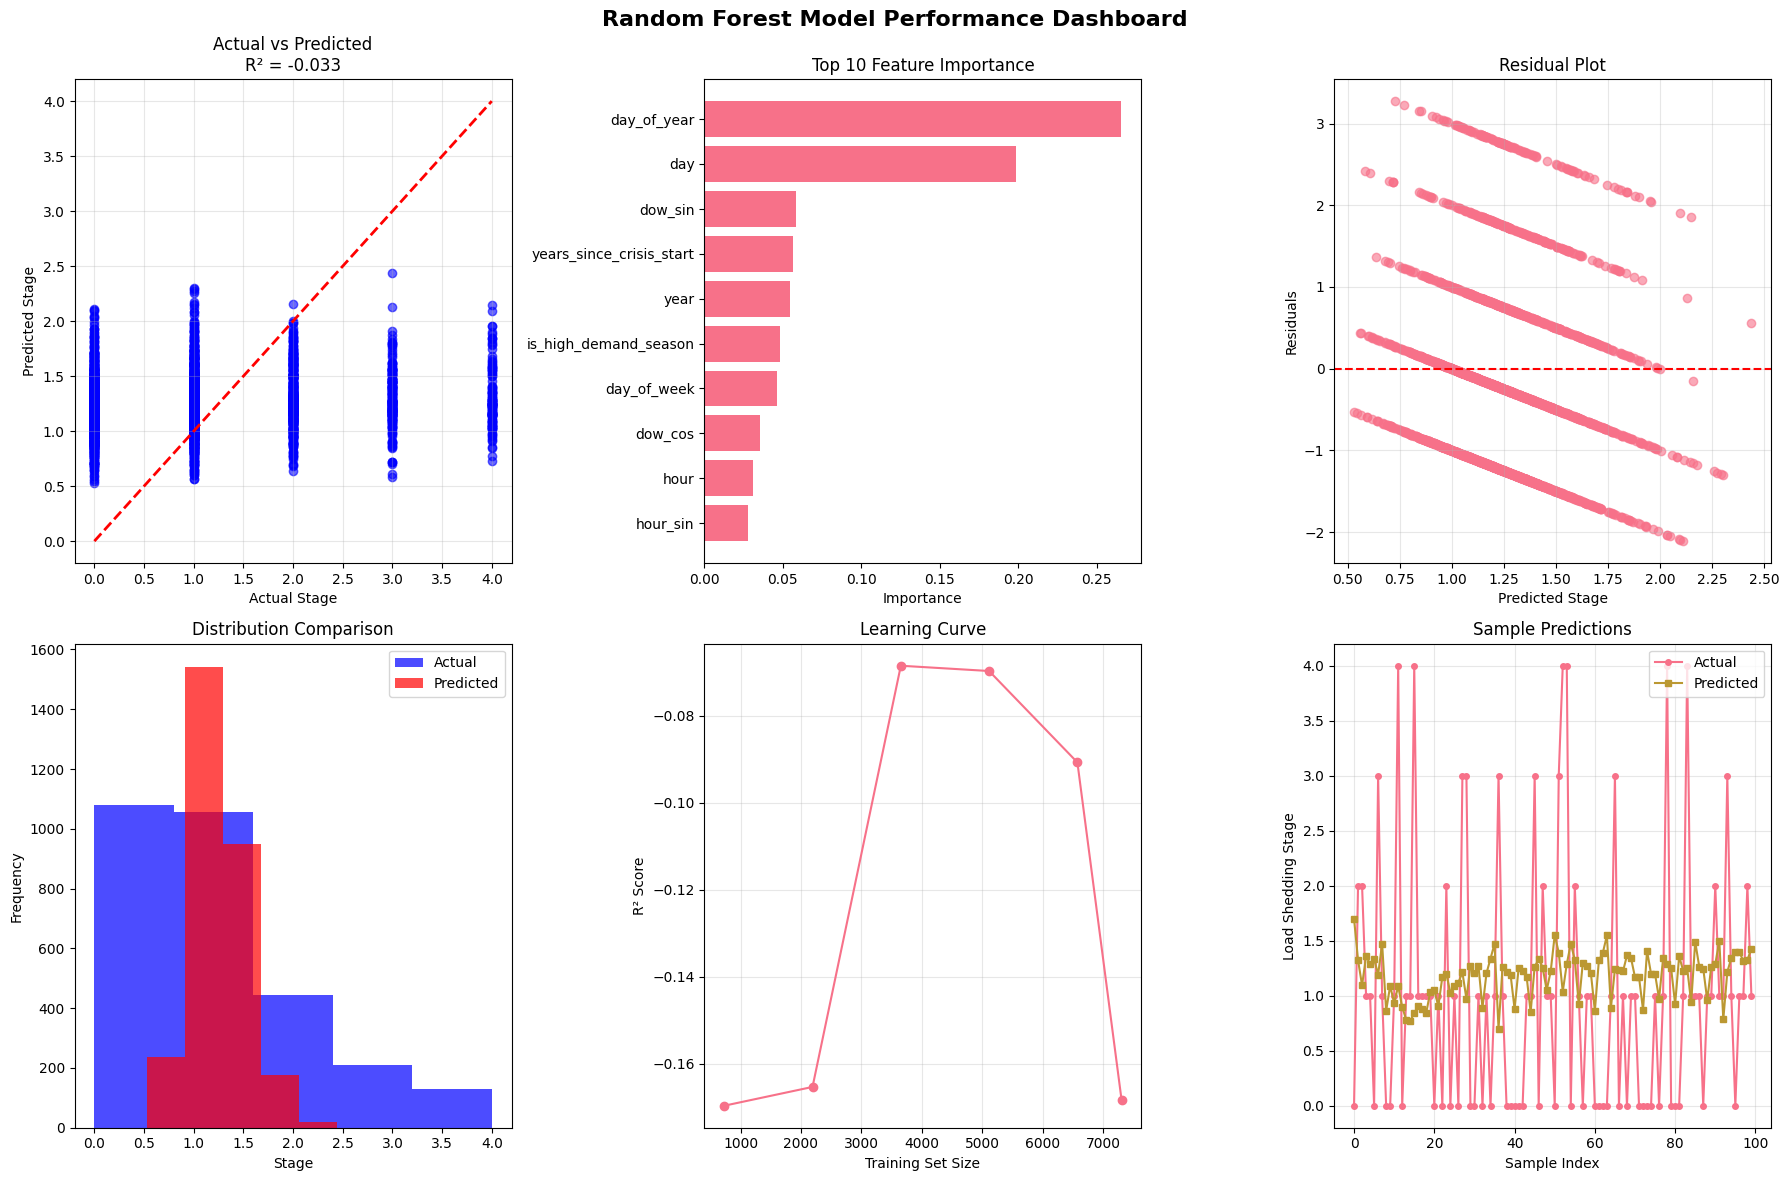


📚 Learning checkpoint: Machine learning model successfully trained and evaluated!
💡 Key insight: day_of_year is the most important predictor.

🎯 PROGRESS CHECKPOINT - Model Training Complete
✅ Model R² Score: -0.033
✅ Model MAE: 0.907 stages
✅ Top predictor: day_of_year
💾 Memory: 1.2GB / 12.7GB (11.9%)
💿 Disk: 37.9GB / 107.7GB (35.2%)

🎯 Next: Save model artifacts to S3


In [53]:
print("🤖 Starting Machine Learning Model Development...")
print("🎯 Goal: Predict load shedding stages using temporal and domain features")

# 🔧 Feature Selection for ML Model
print("\n🔧 Selecting features for machine learning...")

# Select numerical features for ML (exclude text and timestamp columns)
feature_columns = [
    # Temporal features
    'year', 'month', 'day', 'hour', 'day_of_week', 'day_of_year', 'quarter',
    # Binary indicators
    'is_high_demand_season', 'is_weekend', 'is_monday', 'is_friday',
    'is_business_hours', 'is_peak_hours', 'is_night',
    # Trend features
    'years_since_crisis_start', 'is_crisis_escalation', 'is_peak_crisis',
    # Cyclical features
    'month_sin', 'month_cos', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos'
]

# Prepare features and target
X = processed_data[feature_columns]
y = processed_data['stage']  # Target variable

print(f"📊 Features selected: {len(feature_columns)}")
print(f"📈 Training samples: {len(X):,}")
print(f"🎯 Target distribution:")
for stage, count in y.value_counts().sort_index().items():
    percentage = 100 * count / len(y)
    print(f"   Stage {stage}: {count:,} ({percentage:.1f}%)")

# 📊 Train-Test Split (Time-aware)
print("\n📊 Splitting data for training and testing...")
print("💡 Using time-aware split to simulate real-world prediction scenario")

# For time series, use temporal split instead of random split
split_date = '2023-01-01'
train_mask = processed_data['timestamp'] < split_date
test_mask = processed_data['timestamp'] >= split_date

X_train = X[train_mask]
X_test = X[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print(f"📅 Split date: {split_date}")
print(f"🏋️ Training set: {len(X_train):,} samples ({train_mask.sum() / len(processed_data) * 100:.1f}%)")
print(f"🧪 Test set: {len(X_test):,} samples ({test_mask.sum() / len(processed_data) * 100:.1f}%)")

# ⚖️ Feature Scaling
print("\n⚖️ Scaling features for optimal model performance...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features standardized (mean=0, std=1)")

# 🌳 Train Random Forest Model
print("\n🌳 Training Random Forest Regressor...")
print("💡 Random Forest builds multiple decision trees and averages their predictions")

# Initialize model with optimized parameters
rf_model = RandomForestRegressor(
    n_estimators=100,          # Number of trees
    max_depth=10,              # Maximum tree depth
    min_samples_split=5,       # Minimum samples to split
    min_samples_leaf=2,        # Minimum samples in leaf
    random_state=42,           # For reproducibility
    n_jobs=-1                  # Use all CPU cores
)

# Train the model with progress tracking
print("🔧 Training in progress...")
with tqdm(total=1, desc="Training Random Forest") as pbar:
    rf_model.fit(X_train_scaled, y_train)
    pbar.update(1)
print("✅ Model training completed!")


# 📊 Model Predictions
print("\n📊 Generating predictions...")
y_train_pred = rf_model.predict(X_train_scaled)
y_test_pred = rf_model.predict(X_test_scaled)

# 📈 Model Evaluation
print("\n📈 Evaluating model performance...")

# Calculate metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)


print("📊 MODEL PERFORMANCE METRICS:")
print("="*40)
print(f"📈 R² Score (Variance Explained):")
print(f"   Training:   {train_r2:.4f} ({train_r2*100:.1f}%)")
print(f"   Testing:    {test_r2:.4f} ({test_r2*100:.1f}%)")
print(f"   Difference: {abs(train_r2 - test_r2):.4f} ({'Good' if abs(train_r2 - test_r2) < 0.1 else 'Check for overfitting'})")

print(f"\n📉 Mean Squared Error:")
print(f"   Training: {train_mse:.4f}")
print(f"   Testing:  {test_mse:.4f}")

print(f"\n📏 Mean Absolute Error:")
print(f"   Training: {train_mae:.4f} stages")
print(f"   Testing:  {test_mae:.4f} stages")

# 🔍 Feature Importance Analysis
print("\n🔍 Feature Importance Analysis...")
print("💡 Understanding which features drive load shedding predictions")

feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n🏆 TOP 10 MOST IMPORTANT FEATURES:")
print("-" * 40)
for i, (_, row) in enumerate(feature_importance.head(10).iterrows(), 1):
    percentage = row['importance'] * 100
    bar = '█' * int(percentage / 2)  # Visual bar
    print(f"{i:2d}. {row['feature']:<25} {percentage:5.2f}% {bar}")


# 📊 Model Performance Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Actual vs Predicted
axes[0,0].scatter(y_test, y_test_pred, alpha=0.6, color='blue')
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0,0].set_xlabel('Actual Stage')
axes[0,0].set_ylabel('Predicted Stage')
axes[0,0].set_title(f'Actual vs Predicted\nR² = {test_r2:.3f}')
axes[0,0].grid(True, alpha=0.3)


# 2. Feature Importance
axes[0,1].barh(range(10), feature_importance.head(10)['importance'])
axes[0,1].set_yticks(range(10))
axes[0,1].set_yticklabels(feature_importance.head(10)['feature'])
axes[0,1].set_xlabel('Importance')
axes[0,1].set_title('Top 10 Feature Importance')
axes[0,1].invert_yaxis()


# 3. Residuals
residuals = y_test - y_test_pred
axes[0,2].scatter(y_test_pred, residuals, alpha=0.6)
axes[0,2].axhline(y=0, color='r', linestyle='--')
axes[0,2].set_xlabel('Predicted Stage')
axes[0,2].set_ylabel('Residuals')
axes[0,2].set_title('Residual Plot')
axes[0,2].grid(True, alpha=0.3)


# 4. Prediction Distribution
axes[1,0].hist(y_test, bins=5, alpha=0.7, label='Actual', color='blue')
axes[1,0].hist(y_test_pred, bins=5, alpha=0.7, label='Predicted', color='red')
axes[1,0].set_xlabel('Stage')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Distribution Comparison')
axes[1,0].legend()

# 5. Learning Curve
train_sizes = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
train_scores = []
for size in train_sizes:
    n_samples = int(len(X_train_scaled) * size)
    temp_model = RandomForestRegressor(n_estimators=50, random_state=42)
    temp_model.fit(X_train_scaled[:n_samples], y_train.iloc[:n_samples])
    pred = temp_model.predict(X_test_scaled)
    train_scores.append(r2_score(y_test, pred))

axes[1,1].plot([int(s * len(X_train)) for s in train_sizes], train_scores, 'o-')
axes[1,1].set_xlabel('Training Set Size')
axes[1,1].set_ylabel('R² Score')
axes[1,1].set_title('Learning Curve')
axes[1,1].grid(True, alpha=0.3)

# 6. Time Series Prediction Sample
sample_indices = range(min(100, len(y_test)))  # First 100 test samples or less
axes[1,2].plot(sample_indices, y_test.iloc[:len(sample_indices)], 'o-', label='Actual', markersize=4)
axes[1,2].plot(sample_indices, y_test_pred[:len(sample_indices)], 's-', label='Predicted', markersize=4)
axes[1,2].set_xlabel('Sample Index')
axes[1,2].set_ylabel('Load Shedding Stage')
axes[1,2].set_title('Sample Predictions')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)


plt.suptitle('Random Forest Model Performance Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


print("\n📚 Learning checkpoint: Machine learning model successfully trained and evaluated!")
print(f"💡 Key insight: {feature_importance.iloc[0]['feature']} is the most important predictor.")

# 🎯 Progress checkpoint
print("\n" + "="*50)
print("🎯 PROGRESS CHECKPOINT - Model Training Complete")
print("="*50)
print(f"✅ Model R² Score: {test_r2:.3f}")
print(f"✅ Model MAE: {test_mae:.3f} stages")
print(f"✅ Top predictor: {feature_importance.iloc[0]['feature']}")
monitor_system_resources()
print("\n🎯 Next: Save model artifacts to S3")
print("="*50)

# =============================================================================
# 13 · SAVE MODEL ARTIFACTS TO S3
# =============================================================================

In [54]:
print("💾 Saving model artifacts to S3...")
print("🎯 Goal: Create production-ready model package with all necessary components")

# 📊 Compile comprehensive model metadata
model_metadata = {
    'model_info': {
        'model_type': 'RandomForestRegressor',
        'algorithm': 'Random Forest',
        'task_type': 'regression',
        'target_variable': 'stage',
        'pipeline_timestamp': pipeline_timestamp,
        'training_date': datetime.now().isoformat(),
        'model_version': '1.0.0'
    },
    'training_data': {
        'total_samples': len(processed_data),
        'training_samples': len(X_train),
        'test_samples': len(X_test),
        'train_test_split_date': split_date,
        'date_range': {
            'start': processed_data['timestamp'].min().isoformat(),
            'end': processed_data['timestamp'].max().isoformat()
        }
    },
    'model_parameters': {
        'n_estimators': rf_model.n_estimators,
        'max_depth': rf_model.max_depth,
        'min_samples_split': rf_model.min_samples_split,
        'min_samples_leaf': rf_model.min_samples_leaf,
        'random_state': rf_model.random_state
    },
    'performance_metrics': {
        'train_r2': float(train_r2),
        'test_r2': float(test_r2),
        'train_mse': float(train_mse),
        'test_mse': float(test_mse),
        'train_mae': float(train_mae),
        'test_mae': float(test_mae),
        'overfitting_check': {
            'r2_difference': float(abs(train_r2 - test_r2)),
            'is_overfitting': bool(abs(train_r2 - test_r2) > 0.1)
        }
    },
    'features': {
        'feature_columns': feature_columns,
        'feature_count': len(feature_columns),
        'feature_importance': dict(zip(feature_columns, rf_model.feature_importances_.tolist())),
        'top_5_features': feature_importance.head(5)[['feature', 'importance']].to_dict('records')
    },
    'preprocessing': {
        'scaling_method': 'StandardScaler',
        'scaler_mean': scaler.mean_.tolist(),
        'scaler_scale': scaler.scale_.tolist()
    },
    'business_context': {
        'use_case': 'South African Load Shedding Prediction',
        'stakeholders': ['Eskom', 'Municipalities', 'Businesses', 'Citizens'],
        'prediction_horizon': '6 hours',
        'update_frequency': 'Real-time'
    }
}

# 💾 Save model and scaler locally
model_filename = f'rf_model_{pipeline_timestamp}.joblib'
scaler_filename = f'scaler_{pipeline_timestamp}.joblib'
metadata_filename = f'model_metadata_{pipeline_timestamp}.json'

joblib.dump(rf_model, model_filename)
joblib.dump(scaler, scaler_filename)

with open(metadata_filename, 'w') as f:
    json.dump(model_metadata, f, indent=2, default=str)

print(f"✅ Model saved locally: {model_filename}")
print(f"✅ Scaler saved locally: {scaler_filename}")
print(f"✅ Metadata saved locally: {metadata_filename}")

# ☁️ Upload model artifacts to S3
model_s3_key = f'models/{model_filename}'
scaler_s3_key = f'models/{scaler_filename}'
metadata_s3_key = f'models/{metadata_filename}'

try:
    s3_manager.s3.upload_file(model_filename, s3_manager.bucket, model_s3_key)
    print(f"✅ Model uploaded to S3: s3://{s3_manager.bucket}/{model_s3_key}")
except Exception as e:
    print(f"❌ Model upload failed: {e}")

try:
    s3_manager.s3.upload_file(scaler_filename, s3_manager.bucket, scaler_s3_key)
    print(f"✅ Scaler uploaded to S3: s3://{s3_manager.bucket}/{scaler_s3_key}")
except Exception as e:
    print(f"❌ Scaler upload failed: {e}")

try:
    s3_manager.s3.upload_file(metadata_filename, s3_manager.bucket, metadata_s3_key)
    print(f"✅ Metadata uploaded to S3: s3://{s3_manager.bucket}/{metadata_s3_key}")
except Exception as e:
    print(f"❌ Metadata upload failed: {e}")

# 🔍 Verify upload by listing bucket contents
print("\n🔍 Verifying upload - Current bucket contents:")
s3_manager.list_files(prefix="models/")

print("\n📚 Learning checkpoint: Model artifacts are now safely stored in AWS S3!")
print("💡 This allows us to deploy and use the model in other environments.")

# 🎯 Progress checkpoint
print("\n" + "="*50)
print("🎯 PROGRESS CHECKPOINT - Model Saving Complete")
print("="*50)
print(f"✅ Model artifacts saved to S3")
monitor_system_resources()
print("\n🎯 Next: Finish the task")
print("="*50)

💾 Saving model artifacts to S3...
🎯 Goal: Create production-ready model package with all necessary components
✅ Model saved locally: rf_model_20250717_191719.joblib
✅ Scaler saved locally: scaler_20250717_191719.joblib
✅ Metadata saved locally: model_metadata_20250717_191719.json
✅ Model uploaded to S3: s3://sa-loadshedding-20250717191134-f738b9/models/rf_model_20250717_191719.joblib
✅ Scaler uploaded to S3: s3://sa-loadshedding-20250717191134-f738b9/models/scaler_20250717_191719.joblib
✅ Metadata uploaded to S3: s3://sa-loadshedding-20250717191134-f738b9/models/model_metadata_20250717_191719.json

🔍 Verifying upload - Current bucket contents:
📁 Files in s3://sa-loadshedding-20250717191134-f738b9/models/:
    1. 📄 models/model_metadata_20250717_191719.json (4.5 KB)
    2. 📄 models/rf_model_20250717_191719.joblib (5902.0 KB)
    3. 📄 models/scaler_20250717_191719.joblib (1.7 KB)

📊 Total files: 3

📚 Learning checkpoint: Model artifacts are now safely stored in AWS S3!
💡 This allows us t